# Getting started: Neural ODE for logistic growth

This notebook is a minimal starting point for the logistic Neural ODE example from the lecture.

We implement the following features:

- logistic equation: $\dot{x}=r x(1-x/K)$ with $r=2$, $K=1$,
- training data: 16 trajectories, 161 time points per trajectory,
- training windows: $W=25$.

The goal is to learn a neural right-hand side $f_\theta(x)$ from noisy trajectory data.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scipy
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint

# NOTE: torchdiffeq's adaptive solvers (e.g. dopri5) build their rtol/atol tensors in
# float64, which Apple's MPS backend cannot allocate. We therefore avoid MPS here and
# use CUDA (which supports float64) or CPU. These problems are tiny, so CPU is plenty fast.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
np.random.seed(7)

def as_list(x):
    """Plot tensors without relying on the PyTorch-to-NumPy bridge."""
    return x.detach().cpu().tolist()

print("Using device:", device)

Using device: cpu


## 1. Generate training data

For the starter notebook, the data are synthetic: we solve the true logistic equation and then add a small amount of Gaussian observation noise.

In [2]:
## torchdiffeq interface
class TrueLogistic(nn.Module):
    def __init__(self, r=2.0, K=1.0):
        super().__init__()
        self.r = r
        self.K = K

    def forward(self, t, x):
        return self.r * x * (1.0 - x / self.K)


true_rhs = TrueLogistic(r=2.0, K=1.0).to(device)


## scipy interface 


In [3]:
N_TRAJ = 16
N_TIME = 161
T = 4.0

t = torch.linspace(0.0, T, N_TIME, device=device)
dt = t[1] - t[0]

x0_train = torch.linspace(0.02, 0.80, N_TRAJ, device=device).unsqueeze(1)

with torch.no_grad():
    x_obs = odeint(true_rhs, x0_train, t, method="dopri5")  # [N_TIME, N_TRAJ, 1]

x_obs = x_obs.permute(1, 0, 2).contiguous()               # [N_TRAJ, N_TIME, 1]

print("number of training trajectories:", N_TRAJ)
print("points per trajectory:", N_TIME)
print("total scalar observations:", N_TRAJ * N_TIME)
print("x_obs shape:", tuple(x_obs.shape))

number of training trajectories: 16
points per trajectory: 161
total scalar observations: 2576
x_obs shape: (16, 161, 1)


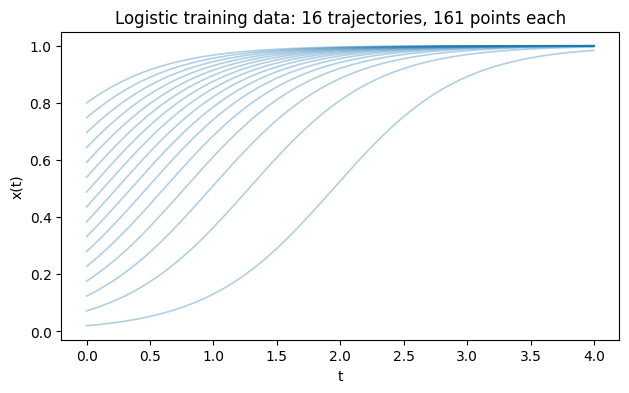

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for j in range(N_TRAJ):
    ax.plot(as_list(t), as_list(x_obs[j, :, 0]), color="C0", alpha=0.35, lw=1.2)
    # ax.scatter(as_list(t[::8]), as_list(x_obs[j, ::8, 0]), color="k", alpha=0.25, s=8)
ax.set_xlabel("t")
ax.set_ylabel("x(t)")
ax.set_title(f"Logistic training data: {N_TRAJ} trajectories, {N_TIME} points each")
plt.show()

## 2. Define a neural vector field

The neural network represents the unknown right-hand side $f_\theta(x)$. The only interface required by `torchdiffeq` is `forward(t, x)`.

In [5]:
class NeuralLogistic(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

        # Normalization buffers make optimization less sensitive to units.
        self.register_buffer("x_mean", torch.zeros(1))
        self.register_buffer("x_std", torch.ones(1))
        self.register_buffer("dxdt_std", torch.ones(1))

    def set_normalization(self, x_mean, x_std, dxdt_std):
        self.x_mean.copy_(x_mean)
        self.x_std.copy_(x_std)
        self.dxdt_std.copy_(dxdt_std)

    def forward(self, t, x):
        x_norm = (x - self.x_mean) / self.x_std
        return self.dxdt_std * self.net(x_norm)

In [6]:
def estimate_normalization(x_data):
    x_flat = x_data.reshape(-1, 1)
    x_mean = x_flat.mean(0)
    x_std = x_flat.std(0).clamp_min(1e-6)

    dxdt = (x_data[:, 1:] - x_data[:, :-1]) / dt
    dxdt_std = dxdt.reshape(-1, 1).std(0).clamp(min=0.2, max=3.0)
    return x_mean, x_std, dxdt_std


model = NeuralLogistic(hidden_dim=32).to(device)
model.set_normalization(*estimate_normalization(x_obs))

print(model)

NeuralLogistic(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 3. Random short-window batching

A training batch consists of random trajectory/start-time pairs. Each item is a short observed trajectory segment of length `WINDOW_SIZE`.

In [7]:
WINDOW_SIZE = 25
BATCH_SIZE = 32

t_window = torch.arange(WINDOW_SIZE, device=device).float() * dt

def sample_window_batch(x_data, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE):
    n_traj, n_time, _ = x_data.shape
    traj_idx = np.random.randint(0, n_traj, size=batch_size)
    starts = np.random.randint(0, n_time - window_size, size=batch_size)

    x0_batch = torch.stack([x_data[j, s] for j, s in zip(traj_idx, starts)])
    y_batch = torch.stack([x_data[j, s:s + window_size] for j, s in zip(traj_idx, starts)])
    return x0_batch, y_batch


x0_batch, y_batch = sample_window_batch(x_obs)
print("x0_batch:", tuple(x0_batch.shape))
print("y_batch:", tuple(y_batch.shape))

x0_batch: (32, 1)
y_batch: (32, 25, 1)


## 4. Train the Neural ODE

The key line is `odeint(model, x0_batch, t_window)`: the neural network is integrated as an ODE right-hand side, then the integrated prediction is compared to the observed window.

In [8]:
optimizer = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.MSELoss()

N_STEPS = 1000
losses = []

for step in range(1, N_STEPS + 1):
    x0_batch, y_batch = sample_window_batch(x_obs)

    pred = odeint(model, x0_batch, t_window, method="rk4")  # [WINDOW_SIZE, BATCH_SIZE, 1]
    target = y_batch.permute(1, 0, 2)                       # [WINDOW_SIZE, BATCH_SIZE, 1]
    loss = loss_fn(pred, target)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
    optimizer.step()

    if step == 1 or step % 10 == 0:
        losses.append((step, float(loss.detach().cpu())))

    if step % 100 == 0:
        print(f"step {step:4d} | loss {loss.item():.4e}")

step  100 | loss 1.4822e-04
step  200 | loss 1.3474e-04
step  300 | loss 8.3438e-05
step  400 | loss 1.9677e-05
step  500 | loss 1.2722e-05
step  600 | loss 2.8235e-06
step  700 | loss 3.1847e-06
step  800 | loss 9.0323e-06
step  900 | loss 3.4804e-06
step 1000 | loss 3.0505e-06


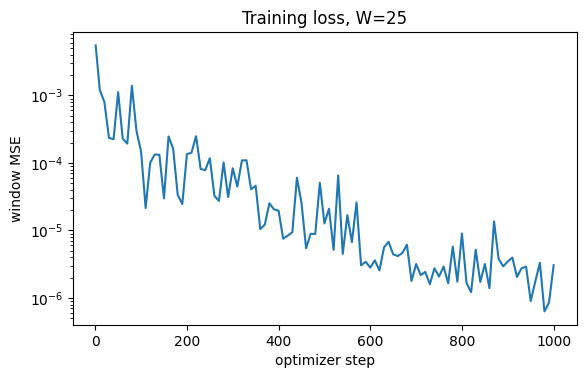

In [9]:
losses = np.array(losses)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(losses[:, 0], losses[:, 1])
ax.set_yscale("log")
ax.set_xlabel("optimizer step")
ax.set_ylabel("window MSE")
ax.set_title(f"Training loss, W={WINDOW_SIZE}")
plt.show()

## 5. Evaluate learned rollouts

Training used noisy windows. Evaluation below compares clean logistic solutions to Neural ODE rollouts from held-out initial conditions.

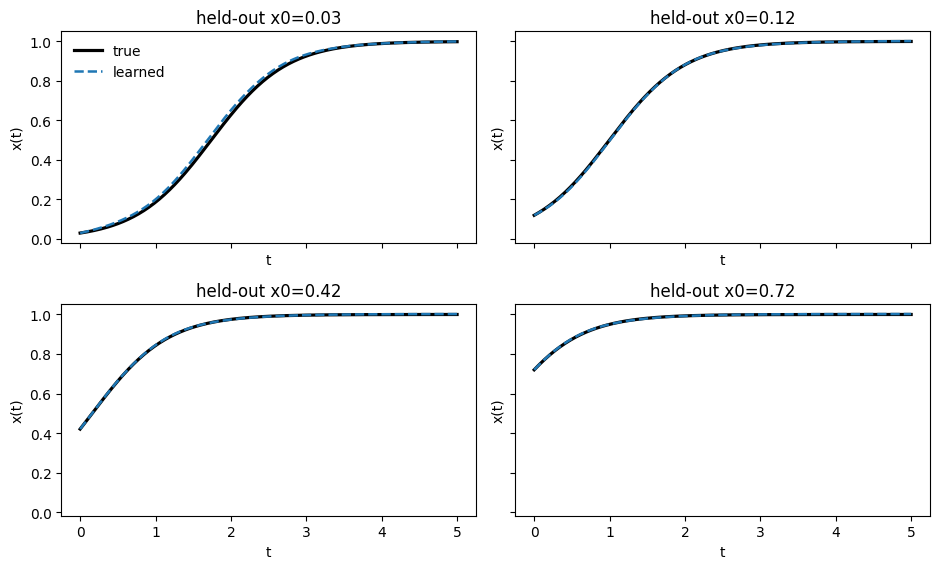

In [10]:
t_eval = torch.linspace(0.0, 5.0, 220, device=device)
x0_eval = torch.tensor([[0.03], [0.12], [0.42], [0.72]], device=device)

with torch.no_grad():
    true_eval = odeint(true_rhs, x0_eval, t_eval, method="dopri5").permute(1, 0, 2)

model.eval()

fig, axes = plt.subplots(2, 2, figsize=(9.5, 5.8), sharex=True, sharey=True)
for ax, i in zip(axes.ravel(), range(x0_eval.shape[0])):
    with torch.no_grad():
        pred = odeint(model, x0_eval[i], t_eval, method="dopri5")[:, 0]

    ax.plot(as_list(t_eval), as_list(true_eval[i, :, 0]), color="k", lw=2.3, label="true")
    ax.plot(as_list(t_eval), as_list(pred), ls='--', color="C0", lw=1.8, label="learned")
    ax.set_title(f"held-out x0={float(x0_eval[i, 0]):.2f}")
    ax.set_xlabel("t")
    ax.set_ylabel("x(t)")

axes[0, 0].legend(frameon=False)
fig.tight_layout()
plt.show()

## 6. Inspect the learned vector field

For this toy problem, we know the true right-hand side. That lets us directly compare $f_\theta(x)$ to $f_\star(x)$.

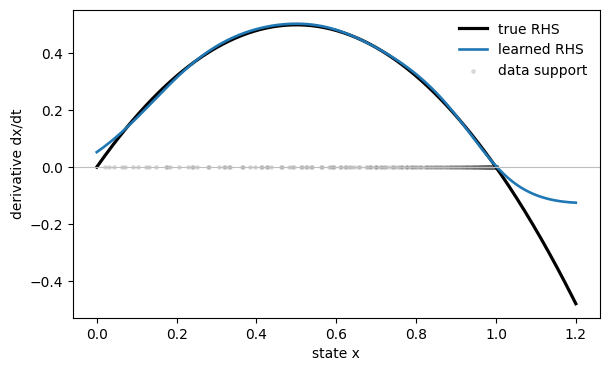

In [11]:
x_grid = torch.linspace(0.0, 1.2, 300, device=device).unsqueeze(1)

with torch.no_grad():
    f_true = true_rhs(0.0, x_grid)
    f_learned = model(0.0, x_grid)

fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.plot(as_list(x_grid[:, 0]), as_list(f_true[:, 0]), color="k", lw=2.3, label="true RHS")
ax.plot(as_list(x_grid[:, 0]), as_list(f_learned[:, 0]), color="C0", lw=1.9, label="learned RHS")
ax.scatter(as_list(x_obs[:, ::8, 0].reshape(-1)), as_list(torch.zeros_like(x_obs[:, ::8, 0]).reshape(-1)), s=6, color="0.4", alpha=0.18, label="data support")
ax.axhline(0, color="0.75", lw=0.8)
ax.set_xlabel("state x")
ax.set_ylabel("derivative dx/dt")
ax.legend(frameon=False)
plt.show()